# 01 Engagement Score

This notebook builds the weekly engagement score as an explainable product metric, not a black-box grade proxy. The unit of analysis is one row per `student_id × module × presentation × week`, and every feature uses behavior available up to that week.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_loader import OUT_DIR, WEEK_CUTOFF, audit_and_clean_data, ensure_dirs, load_data
from evaluation import plot_data_quality, plot_engagement_outputs
from features import build_weekly_base_features, feature_rationale, make_enrollment_split, task1_feature_catalog as build_task1_feature_catalog
from scoring import apply_engagement_score, derive_engagement_weights, select_archetypes, validate_engagement_score

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")
ensure_dirs()


## 1. Load And Audit The Data

Before modelling, we verify the enrolment key, missingness, date semantics, and leakage boundaries. The key point for this project is that `studentVle.date` is measured as days from module-presentation start. Negative dates are valid pre-start activity, so they are useful for proactivity rather than something to drop.


In [2]:
raw_data = load_data()
data, audits = audit_and_clean_data(raw_data)
plot_data_quality(audits, data)

audits["overview"]


,table,rows,columns,duplicate_rows,missing_cells
0,courses,22,3,0,0
1,student_info,32593,12,0,1111
2,registration,32593,5,0,22566
3,assessments,206,6,0,11
4,student_assessment,173912,5,0,173
5,vle,6364,6,0,10486
6,student_vle,10655280,6,787170,0


In [3]:
audits["missingness"].sort_values("missing_pct", ascending=False).head(12)


,table,column,missing_count,missing_pct
5,vle,week_from,5243,0.823853
6,vle,week_to,5243,0.823853
2,registration,date_unregistration,22521,0.690977
3,assessments,date,11,0.053398
0,student_info,imd_band,1111,0.034087
1,registration,date_registration,45,0.001381
4,student_assessment,score,173,0.000995


In [4]:
audits["consistency"]


,check,issue_count,policy
0,studentInfo key uniqueness,0,Use student-module-presentation as the enrolme...
1,studentRegistration key uniqueness,0,Use student-module-presentation as the enrolme...
2,Unregistered enrolments not labelled Withdrawn,9,Audit only; official final_result remains the ...
3,Withdrawn enrolments without unregistration date,93,Do not use date_unregistration as a predictive...
4,Missing score rows,173,Keep missing scores as missing; median-impute ...
5,Invalid score rows outside 0-100,0,Invalid values would be excluded from score ag...
6,Assessment rows with missing due date,11,Exclude missing-date assessments from weekly d...
7,Negative VLE activity dates (pre-start engagem...,688988,Valid pre-presentation activity; date is days ...
8,VLE activity after module presentation length,0,Exclude from weekly engagement panel.
9,Missing VLE week_from/week_to metadata,10486,Do not use week_from/week_to as model features.


In [5]:
audits["leakage"]


,candidate_feature,available_by_week6,used,reason
0,Pre-start VLE activity (negative dates),Yes,Yes,Observed before day 0; reflects eagerness to b...
1,Week 1-6 VLE clicks,Yes,Yes,Observed before the Week 6 prediction point.
2,Week 1-6 active days,Yes,Yes,Observed before the Week 6 prediction point.
3,Week 1-6 activity diversity,Yes,Yes,Observed before the Week 6 prediction point.
4,Early non-exam assessment submissions,Yes,Yes,Only due/submitted work by Week 6 is used.
5,Student demographics/context,Yes,Yes,Known at registration or course enrolment.
6,Engagement score,Yes,Yes,Computed from Week 1-6 behavior using train-de...
7,Final result,No,Target only,Used only to train/evaluate the supervised label.
8,Final exam score,No,No,Not available by Week 6.
9,Full-semester total clicks,No,No,Would leak future engagement behavior.


## 2. Outcome And Course Context

A useful PathAI score needs to work across modules and presentations, so the first check is whether risk rates vary materially by course. This motivates peer-normalizing behavioural features within `module + presentation + week`, instead of comparing every student against the whole dataset.


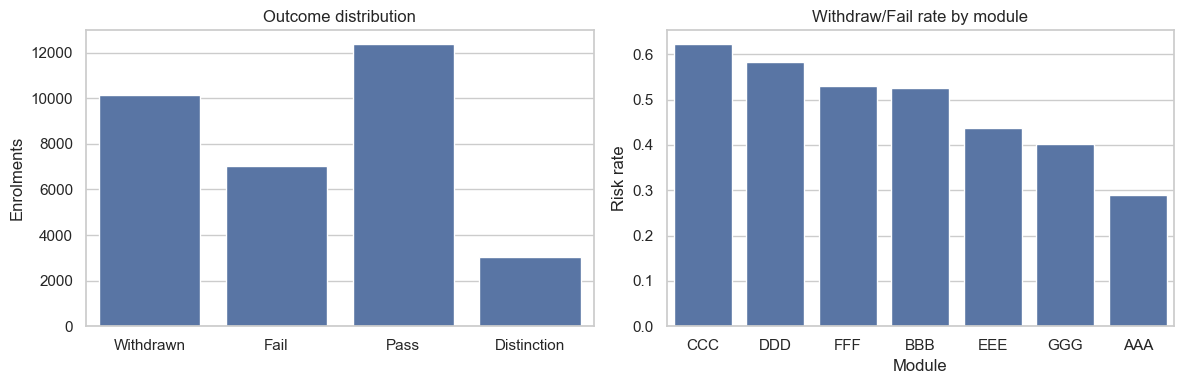

In [6]:
outcome = data["student_info"].copy()
outcome["risk_label"] = outcome["final_result"].isin(["Withdrawn", "Fail"]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=outcome, x="final_result", order=["Withdrawn", "Fail", "Pass", "Distinction"], ax=axes[0])
axes[0].set_title("Outcome distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Enrolments")

module_risk = outcome.groupby("code_module", as_index=False)["risk_label"].mean().sort_values("risk_label", ascending=False)
sns.barplot(data=module_risk, x="code_module", y="risk_label", ax=axes[1])
axes[1].set_title("Withdraw/Fail rate by module")
axes[1].set_xlabel("Module")
axes[1].set_ylabel("Risk rate")
plt.tight_layout()


## 3. Candidate Feature Logic: Six Behavioural Buckets

OULAD does not provide time-on-page or session duration. Because of that, raw clicks alone are a weak proxy: one learner could click once and work deeply, while another could generate many clicks with little sustained study. The feature framework therefore groups behaviour into six interpretable buckets:

1. **Activity volume** — how much the student interacts with the VLE.
2. **Consistency and rhythm** — whether engagement is steady or binge-like.
3. **Recency and disengagement gaps** — whether the student has recently disappeared.
4. **Resource diversity and intent** — whether clicks reflect broad, study-oriented, social, or assessment-oriented engagement.
5. **Course-pace alignment** — whether the student starts early, stays on schedule, studies ahead, or catches up late.
6. **Assessment behaviour and recovery** — whether the student submits work, prepares before deadlines, crams, or recovers after weak scores.

The final 0-100 score remains simple, but the notebook keeps the wider feature catalog visible for explanation, archetypes, and Task 2 modelling. Components with train success AUC at or below 0.50 are assigned 0% score weight, because a trusted administrator-facing score should not be moved by signals that are weaker than random in the current definition.

In [7]:
weekly_base = build_weekly_base_features(data)
weekly_base[[
    "code_module", "code_presentation", "id_student", "week",
    "weekly_clicks_norm", "active_days_last_7", "days_since_last_click",
    "activity_diversity", "material_active_days", "material_click_share", "forum_clicks", "zero_click_weeks_cum", "recent_clicks_2w", "click_trend_3w",
    "assessment_submitted_ratio", "punctuality_ratio", "low_weight_completion_ratio",
    "pre_start_clicks", "days_before_start", "pre_start_proactivity_raw",
]].head(10)


,code_module,code_presentation,id_student,week,weekly_clicks_norm,active_days_last_7,days_since_last_click,activity_diversity,material_active_days,material_click_share,forum_clicks,zero_click_weeks_cum,recent_clicks_2w,click_trend_3w,assessment_submitted_ratio,punctuality_ratio,low_weight_completion_ratio,pre_start_clicks,days_before_start,pre_start_proactivity_raw
0,AAA,2013J,11391,1,0.874674,4.0,0.0,6.0,4.0,0.775956,18.0,0,183.0,0.0,1.0,1.0,1.0,98.0,5.0,0.303916
1,AAA,2013J,11391,2,0.241514,1.0,4.0,3.0,1.0,0.950000,0.0,0,203.0,-163.0,1.0,1.0,1.0,98.0,5.0,0.303916
2,AAA,2013J,11391,3,0.566580,2.0,2.0,5.0,2.0,0.540000,35.0,0,120.0,-41.5,1.0,1.0,1.0,98.0,5.0,0.303916
3,AAA,2013J,11391,4,0.103133,0.0,9.0,0.0,0.0,0.000000,0.0,1,100.0,-10.0,1.0,1.0,1.0,98.0,5.0,0.303916
4,AAA,2013J,11391,5,0.445170,3.0,3.0,4.0,2.0,0.538462,2.0,1,26.0,-37.0,1.0,1.0,1.0,98.0,5.0,0.303916
5,AAA,2013J,11391,6,0.687990,2.0,1.0,4.0,1.0,0.516667,23.0,1,86.0,30.0,1.0,1.0,1.0,98.0,5.0,0.303916
6,AAA,2013J,11391,7,0.443864,2.0,0.0,2.0,0.0,0.000000,18.0,1,82.0,-2.0,1.0,1.0,1.0,98.0,5.0,0.303916
7,AAA,2013J,11391,8,0.315927,3.0,1.0,2.0,1.0,0.750000,0.0,1,42.0,-20.0,1.0,1.0,1.0,98.0,5.0,0.303916
8,AAA,2013J,11391,9,0.134465,0.0,8.0,0.0,0.0,0.000000,0.0,2,20.0,-11.0,1.0,1.0,1.0,98.0,5.0,0.303916
9,AAA,2013J,11391,10,0.545692,1.0,4.0,2.0,1.0,0.812500,0.0,2,16.0,-2.0,1.0,1.0,1.0,98.0,5.0,0.303916


### Feature Catalog By Bucket

The table below documents the engineered features and the product interpretation behind each one. This is the clearest way to show that feature engineering was intentional rather than arbitrary.


In [8]:
task1_feature_catalog = build_task1_feature_catalog()
task1_feature_catalog


,bucket,feature,description
0,Activity volume,weekly_clicks_norm,Peer-normalized weekly activity volume.
1,Activity volume,weekly_clicks,Raw weekly click count used for diagnostic plo...
2,Activity volume,unique_sites_wk,Breadth of distinct VLE sites touched in the w...
3,Consistency and rhythm,active_days_last_7,Count of distinct active days in the week.
4,Consistency and rhythm,study_regularity_score,Active days divided by seven.
5,Consistency and rhythm,click_gini_wk,Inequality of daily clicks; high values sugges...
6,Consistency and rhythm,burstiness_score,Share of weekly clicks concentrated on the bus...
7,Consistency and rhythm,week_to_week_volatility,Rolling four-week standard deviation of weekly...
8,Consistency and rhythm,zero_click_weeks_cum,Cumulative weeks with no VLE activity.
9,Recency and disengagement gaps,days_since_last_click,Days since the student's most recent VLE inter...


## 4. Feature Evidence At Week 6

The assignment requires data-backed justification. The table below compares Week 6 feature means for withdraw/fail versus pass/distinction and computes correlation with the risk label. This is not treated as causal proof; it is a sanity check that the score components point in plausible directions.


In [9]:
week6 = weekly_base[weekly_base["week"] == WEEK_CUTOFF].copy()
week6["risk_label"] = week6["final_result"].isin(["Withdrawn", "Fail"]).astype(int)

task1_feature_catalog = build_task1_feature_catalog()
candidate_features = [feature for feature in task1_feature_catalog["feature"] if feature in week6.columns and feature != "engagement_score"]

feature_screen = []
for feature in candidate_features:
    catalog_row = task1_feature_catalog.loc[task1_feature_catalog["feature"] == feature].iloc[0]
    feature_screen.append({
        "bucket": catalog_row["bucket"],
        "feature": feature,
        "readable_label": catalog_row["description"],
        "withdraw_fail_mean": week6.loc[week6["risk_label"] == 1, feature].mean(),
        "pass_distinction_mean": week6.loc[week6["risk_label"] == 0, feature].mean(),
        "risk_correlation": week6[[feature, "risk_label"]].corr(numeric_only=True).iloc[0, 1],
    })
feature_screen = pd.DataFrame(feature_screen)
feature_screen["abs_correlation"] = feature_screen["risk_correlation"].abs()
feature_screen["direction"] = feature_screen["risk_correlation"].apply(
    lambda r: "Higher value is associated with lower withdraw/fail risk" if r < 0 else "Higher value is associated with higher withdraw/fail risk"
)

core_feature_correlations = feature_screen.sort_values("abs_correlation", ascending=False).head(15)
core_feature_correlations[[
    "bucket", "feature", "readable_label", "risk_correlation", "withdraw_fail_mean", "pass_distinction_mean", "direction"
]]


,bucket,feature,readable_label,risk_correlation,withdraw_fail_mean,pass_distinction_mean,direction
36,Assessment behavior and recovery,assessment_submitted_ratio,Cumulative due assessment completion.,-0.485747,0.558984,0.963926,Higher value is associated with lower withdraw...
8,Consistency and rhythm,zero_click_weeks_cum,Cumulative weeks with no VLE activity.,0.473320,2.844607,0.767176,Higher value is associated with higher withdra...
0,Activity volume,weekly_clicks_norm,Peer-normalized weekly activity volume.,-0.467630,0.376851,0.638456,Higher value is associated with lower withdraw...
37,Assessment behavior and recovery,missed_assessments_cum,Cumulative due assessments not submitted.,0.452782,0.607508,0.058239,Higher value is associated with higher withdra...
12,Recency and disengagement gaps,inactive_last_14_days,Flag that the student has been absent for at l...,0.438877,0.452813,0.063048,Higher value is associated with higher withdra...
11,Recency and disengagement gaps,inactive_last_7_days,Flag that the student has been absent for at l...,0.438531,0.576069,0.150731,Higher value is associated with higher withdra...
3,Consistency and rhythm,active_days_last_7,Count of distinct active days in the week.,-0.420454,1.100360,2.852649,Higher value is associated with lower withdraw...
4,Consistency and rhythm,study_regularity_score,Active days divided by seven.,-0.420454,0.157194,0.407521,Higher value is associated with lower withdraw...
15,Resource diversity and intent,activity_diversity,Distinct VLE activity types used in the week.,-0.409821,1.604370,3.642054,Higher value is associated with lower withdraw...
16,Resource diversity and intent,activity_entropy_wk,Balance of clicks across activity types.,-0.394332,0.568248,1.251178,Higher value is associated with lower withdraw...


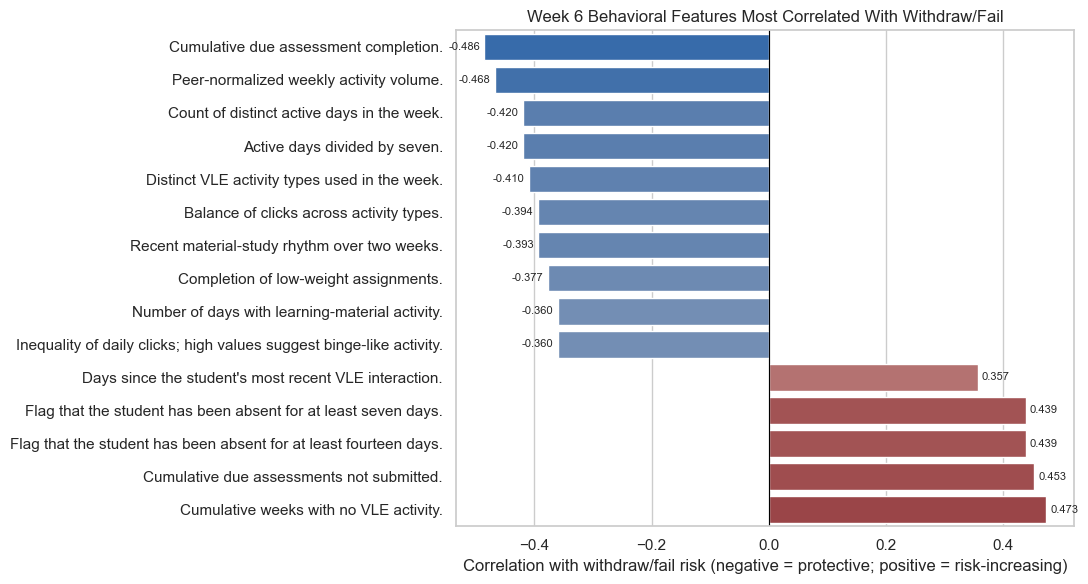

In [10]:
plot_df = core_feature_correlations.sort_values("risk_correlation")
plt.figure(figsize=(11, 6))
ax = sns.barplot(data=plot_df, y="readable_label", x="risk_correlation", hue="risk_correlation", palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Week 6 Behavioral Features Most Correlated With Withdraw/Fail")
plt.xlabel("Correlation with withdraw/fail risk (negative = protective; positive = risk-increasing)")
plt.ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
plt.tight_layout()


### Reading The Correlation Evidence

The strongest protective signals are assessment completion, peer-normalized VLE activity, active-day consistency, activity diversity, material-study behaviour, and pre-start proactivity. `days_since_last_click` moves in the opposite direction because a larger recency gap means the student has been absent longer. These correlations are not used as causal proof; they are used as transparent evidence that the score components are directionally sensible.


In [11]:
bucket_summary = (
    feature_screen.groupby("bucket")
    .agg(
        features_tested=("feature", "count"),
        strongest_abs_corr=("abs_correlation", "max"),
        median_abs_corr=("abs_correlation", "median"),
    )
    .sort_values("strongest_abs_corr", ascending=False)
    .reset_index()
)
bucket_summary


,bucket,features_tested,strongest_abs_corr,median_abs_corr
0,Assessment behavior and recovery,10,0.485747,0.193078
1,Consistency and rhythm,6,0.473320,0.390240
2,Activity volume,3,0.467630,0.336081
3,Recency and disengagement gaps,6,0.438877,0.335238
4,Resource diversity and intent,11,0.409821,0.274644
5,Course-pace alignment,10,0.332050,0.207519


## 5. Train-Derived Engagement Score Weights

To avoid hand-wavy weights, the scorecard uses the training split only. Each component receives weight based on its Week 6 ability to separate successful students from withdraw/fail students, then weights are rounded into a readable scorecard. This keeps the score explainable while still grounded in the data.


In [12]:
split = make_enrollment_split(weekly_base)
weights, weight_rationale = derive_engagement_weights(weekly_base, split)
weekly = apply_engagement_score(weekly_base, weights)
weekly.to_csv(OUT_DIR / "weekly_engagement_features.csv", index=False)
weekly[["code_module", "code_presentation", "id_student", "week", "final_result", "engagement_score"]].to_csv(
    OUT_DIR / "weekly_engagement_scores.csv", index=False
)

weight_rationale


,component,label,success_auc,signal_over_random,scorecard_decision,raw_weight,score_weight
1,p_clicks,Peer-normalized click volume,0.773774,0.273774,Included in scorecard,0.142637,0.15
3,p_studiousness,Module-material study frequency,0.741234,0.241234,Included in scorecard,0.125684,0.15
4,p_activity_diversity,Activity diversity,0.761657,0.261657,Included in scorecard,0.136324,0.15
5,p_recency,Recent activity,0.772817,0.272817,Included in scorecard,0.142138,0.15
0,p_pre_start_proactivity,Pre-start course material engagement,0.690147,0.190147,Included in scorecard,0.099067,0.10
2,p_active_days,Active-day consistency,0.777662,0.277662,Included in scorecard,0.144663,0.10
7,p_submission_completion,Assessment completion,0.717889,0.217889,Included in scorecard,0.113521,0.10
9,p_low_weight_completion,Low-weight assignment completion,0.684195,0.184195,Included in scorecard,0.095966,0.10
6,p_trend,Three-week trend,0.481156,0.000000,"Excluded from scorecard: train AUC <= 0.50, so...",0.000000,0.00
8,p_punctuality,Assessment punctuality,0.469309,0.000000,"Excluded from scorecard: train AUC <= 0.50, so...",0.000000,0.00


## 6. Validate Score Behaviour

A transparent score should change week-by-week and map to observed outcomes. We validate it in two ways: score bands versus observed withdraw/fail rate, and representative student trajectories.


In [13]:
score_band_risk = validate_engagement_score(weekly)
feature_rationale_df = feature_rationale(weekly)
archetypes = select_archetypes(weekly)
plot_engagement_outputs(archetypes, score_band_risk, feature_rationale_df)

archetype_definitions = pd.read_csv(OUT_DIR / "engagement_archetype_definitions.csv")
score_band_risk


,score_band,enrolments,observed_withdraw_fail_rate,avg_score
0,0-20,4224,0.983665,17.345478
1,20-40,8237,0.736433,29.738448
2,40-60,7015,0.464718,51.221126
3,60-80,10549,0.307043,69.936108
4,80-100,2568,0.190031,83.905023


## 7. Representative Student Archetypes

The archetypes are selected with transparent feature rules rather than manually picked stories. The report splits the trajectory chart into core archetypes and additional behavioral archetypes so the patterns remain readable.


In [14]:
archetype_definitions[[
    "archetype", "description", "feature_signature", "id_student", "code_module", "code_presentation", "final_result",
    "mean_score", "score_range", "zero_click_weeks", "assessment_submitted_ratio", "punctuality_ratio",
    "avg_material_click_share", "avg_activity_diversity"
]]


,archetype,description,feature_signature,id_student,code_module,code_presentation,final_result,mean_score,score_range,zero_click_weeks,assessment_submitted_ratio,punctuality_ratio,avg_material_click_share,avg_activity_diversity
0,Steady Engager,Maintains consistently strong engagement acros...,"High mean engagement score, low score volatili...",635416,CCC,2014B,Pass,83.854286,8.5,0,0.50,0.000000,0.483484,6.000000
1,Early Dropout,Disengages early and does not recover.,"Sharp negative early-to-late score delta, low ...",548415,FFF,2013B,Withdrawn,41.877143,56.7,29,0.25,1.000000,0.072870,1.428571
2,Late Recoverer,Starts weakly but improves later in the semester.,Large positive score delta from early weeks to...,569093,GGG,2014B,Pass,45.571429,61.8,24,1.00,0.333333,0.105079,1.257143
3,Sporadic / Burst Engager,"Works in intense, irregular bursts rather than...","High score range, high max score, and several ...",420724,BBB,2013J,Fail,46.428205,67.6,29,1.00,0.000000,0.046602,0.641026
4,Perfectionist Procrastinator,Delays participation or submissions while stil...,Successful/high-scoring enrolment with late su...,414350,BBB,2013J,Distinction,84.969231,31.9,2,1.00,0.000000,0.212671,4.153846
5,Surface Level / Compliance Engager,Does the minimum required to pass or complete ...,High assessment completion but low activity di...,327940,BBB,2014J,Pass,33.818421,18.8,38,1.00,1.000000,0.000000,0.000000
6,Opportunistic Engager,Selectively engages when material appears usef...,High material-click share and engagement spike...,525635,DDD,2014B,Fail,62.831429,53.4,10,1.00,0.833333,0.626472,2.171429


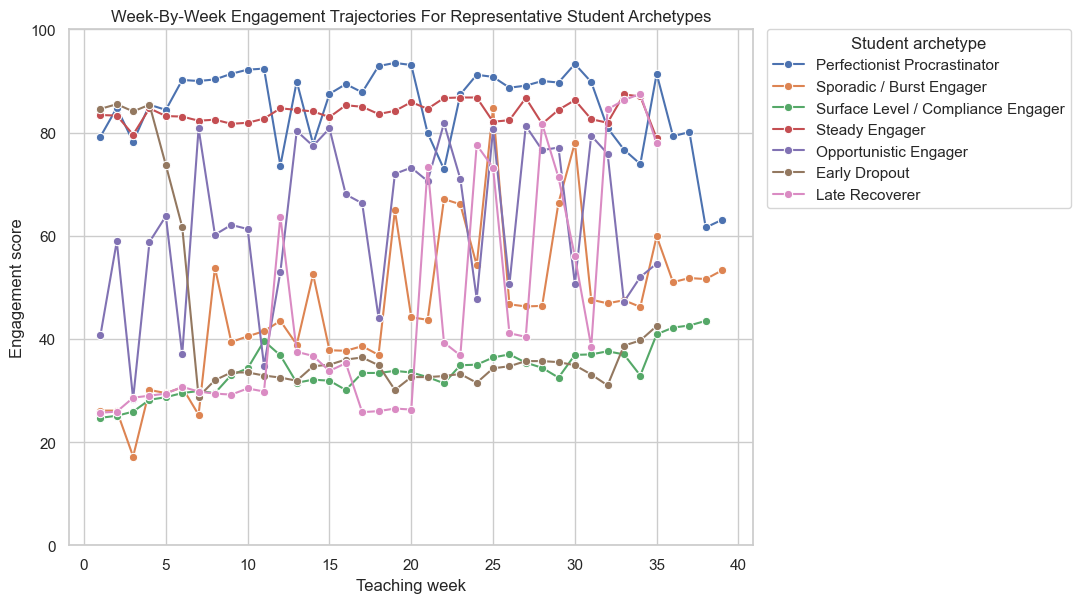

In [15]:
plt.figure(figsize=(11, 6.2))
sns.lineplot(data=archetypes, x="week", y="engagement_score", hue="archetype", marker="o")
plt.ylim(0, 100)
plt.title("Week-By-Week Engagement Trajectories For Representative Student Archetypes")
plt.xlabel("Teaching week")
plt.ylabel("Engagement score")
plt.legend(title="Student archetype", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()


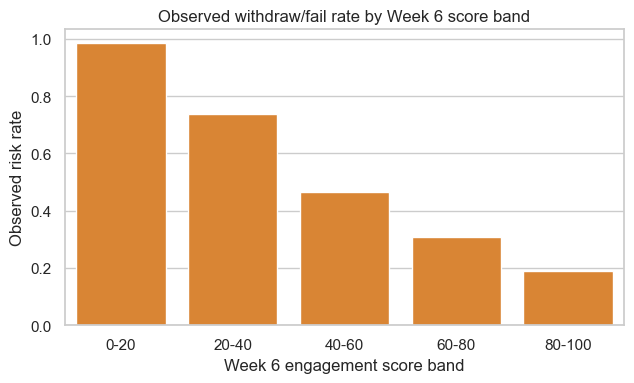

In [16]:
plt.figure(figsize=(6.5, 4))
sns.barplot(data=score_band_risk, x="score_band", y="observed_withdraw_fail_rate", color="#F58518")
plt.title("Observed withdraw/fail rate by Week 6 score band")
plt.xlabel("Week 6 engagement score band")
plt.ylabel("Observed risk rate")
plt.tight_layout()


## Decision

The final engagement score keeps the most understandable behavioural signals as score components, while the wider feature catalog supports explanation, archetype detection, and Task 2 modelling. The key design choice is that clicks are not treated as learning time. Instead, the score and evidence tables triangulate engagement through activity volume, rhythm, recency, resource intent, course-pace alignment, and assessment behaviour.